In [1]:
import pandas as pd
from powerball_ticket_generator import TemperatureLotteryGenerator
from powerball_backtester import PowerballBacktester
from jackpots_scraper import Jackpots

In [2]:
# Update Jackpots dataset
Jackpots().to_csv("jackpots.csv")

'jackpots.csv'

In [3]:
generator = TemperatureLotteryGenerator(
    csv_path="powerball.csv",
    T_white_min=0.0,
    T_red_min=0.0,
    temperature_scale=200.0,          # makes 200 map to alpha≈1
    temperature_sampling="rev_log1p", # mostly high T, few low T
)

tix = generator.generate_ticket_batch(
    n=5,
    max_T=200,
    include_metadata=False
)

tix = pd.DataFrame(tix)
tix

,white_1,white_2,white_3,white_4,white_5,red_ball
0,6,16,22,37,59,14
1,16,38,48,49,69,23
2,7,31,38,54,69,6
3,5,10,23,36,39,18
4,26,28,37,38,49,1



### 1) Baseline single-run backtest (fixed spend, multiplier on, temperatures stored)

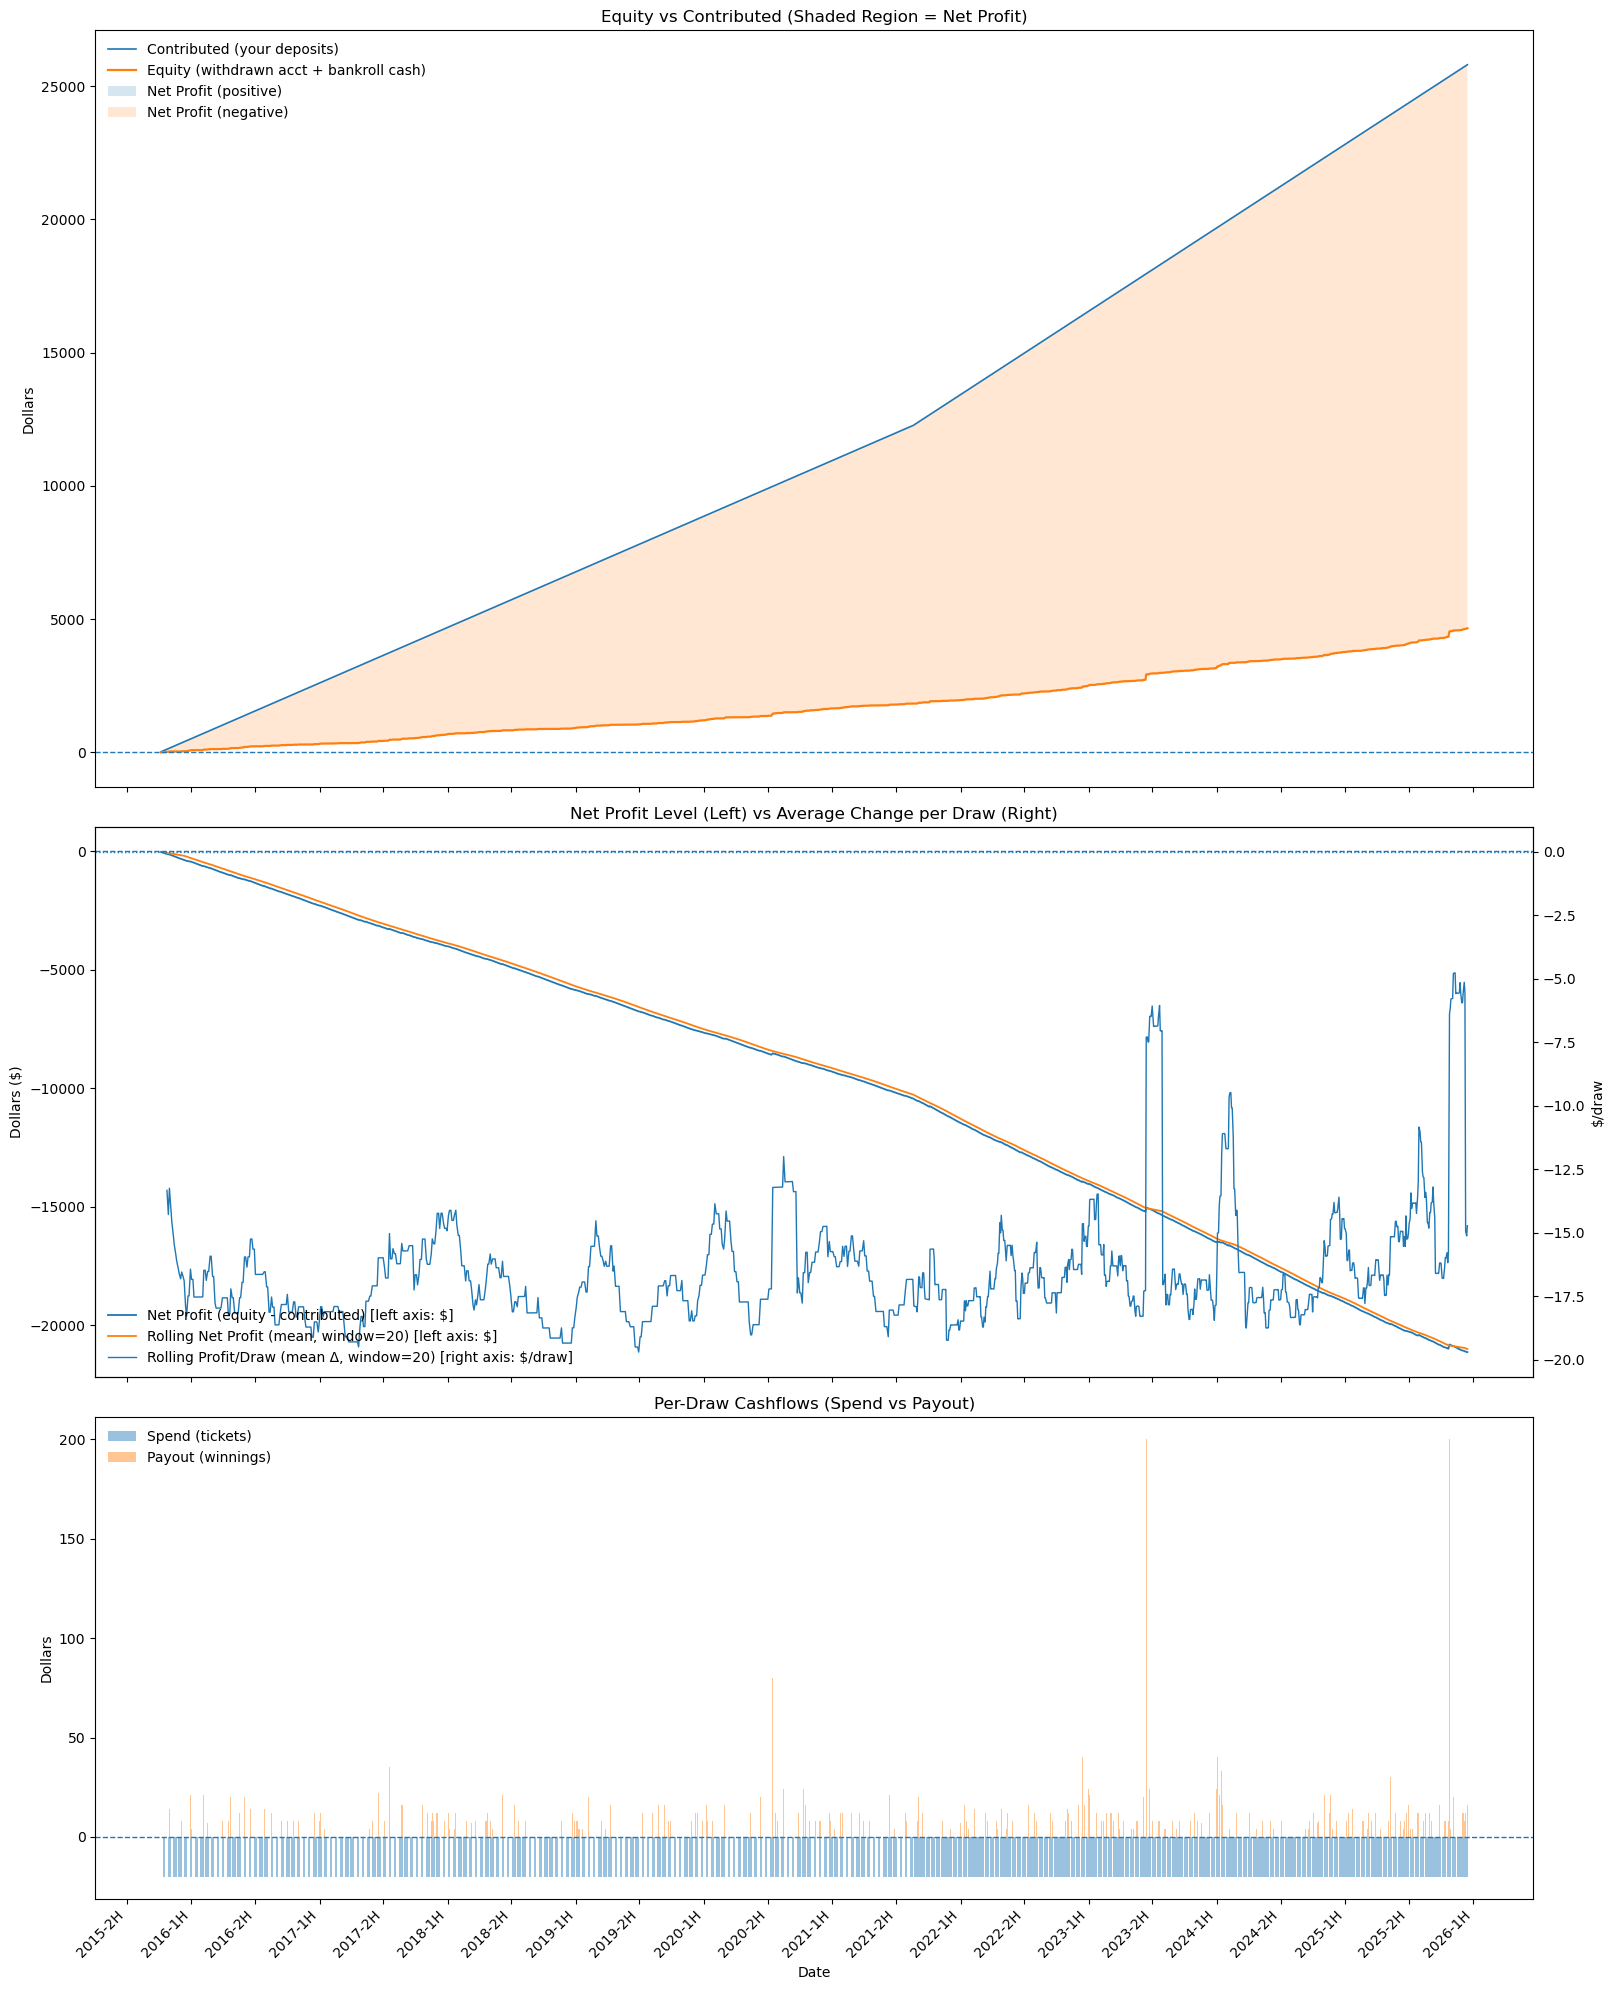

In [4]:
gen = TemperatureLotteryGenerator(
    csv_path="powerball.csv",
    T_white_min=0.0,
    T_red_min=0.0,
    temperature_scale=200.0,          # makes 200 map to alpha≈1
    temperature_sampling="rev_log1p", # mostly high T, few low T
)

bt = PowerballBacktester(
    draw_csv="powerball.csv",
    jackpot_csv="jackpots.csv",
    generator=gen,
    ticket_budget=20,
    use_multiplier=True,
    reinvest_percent=0.0,
    store_temperatures=True,
    rolling_window=20,
    prefer_numba=True,
    withdrawal_apy=0.03,
    max_T=1
)

out = bt.run(seed=None)
bt.plot_winnings(out)

In [5]:
bt.pnl_table 

,date,equity,net_profit,contributed,available,spend,draw_payout,withdrawn,withdrawn_balance,bankroll_cash
0,10/07/2015,0.000000,-20.000000,20.0,20.0,20.0,0.0,0.0,0.000000,0.0
1,10/10/2015,8.000000,-32.000000,40.0,20.0,20.0,8.0,8.0,8.000000,0.0
2,10/14/2015,8.002590,-51.997410,60.0,20.0,20.0,0.0,0.0,8.002590,0.0
3,10/17/2015,8.004533,-71.995467,80.0,20.0,20.0,0.0,0.0,8.004533,0.0
4,10/21/2015,8.007125,-91.992875,100.0,20.0,20.0,0.0,0.0,8.007125,0.0
...,...,...,...,...,...,...,...,...,...,...
1285,12/06/2025,4625.346479,-21094.653521,25720.0,20.0,20.0,8.0,8.0,4625.346479,0.0
1286,12/08/2025,4626.095176,-21113.904824,25740.0,20.0,20.0,0.0,0.0,4626.095176,0.0
1287,12/10/2025,4638.843994,-21121.156006,25760.0,20.0,20.0,12.0,12.0,4638.843994,0.0
1288,12/13/2025,4639.970362,-21140.029638,25780.0,20.0,20.0,0.0,0.0,4639.970362,0.0


### 2) Determinism/regression test harness (repeatability + RNG isolation)

In [6]:
out1 = bt.run(seed=123456)
ticket1 = bt.last_ticket_detail.copy()

out2 = bt.run(seed=123456)
ticket2 = bt.last_ticket_detail.copy()

assert out1.equals(out2)
assert ticket1.equals(ticket2)
assert out1["net_profit"].iat[-1] == out2["net_profit"].iat[-1]  # scalar compare

### 3) Compare reinvestment policies (fixed_exposure vs nested_compounding)

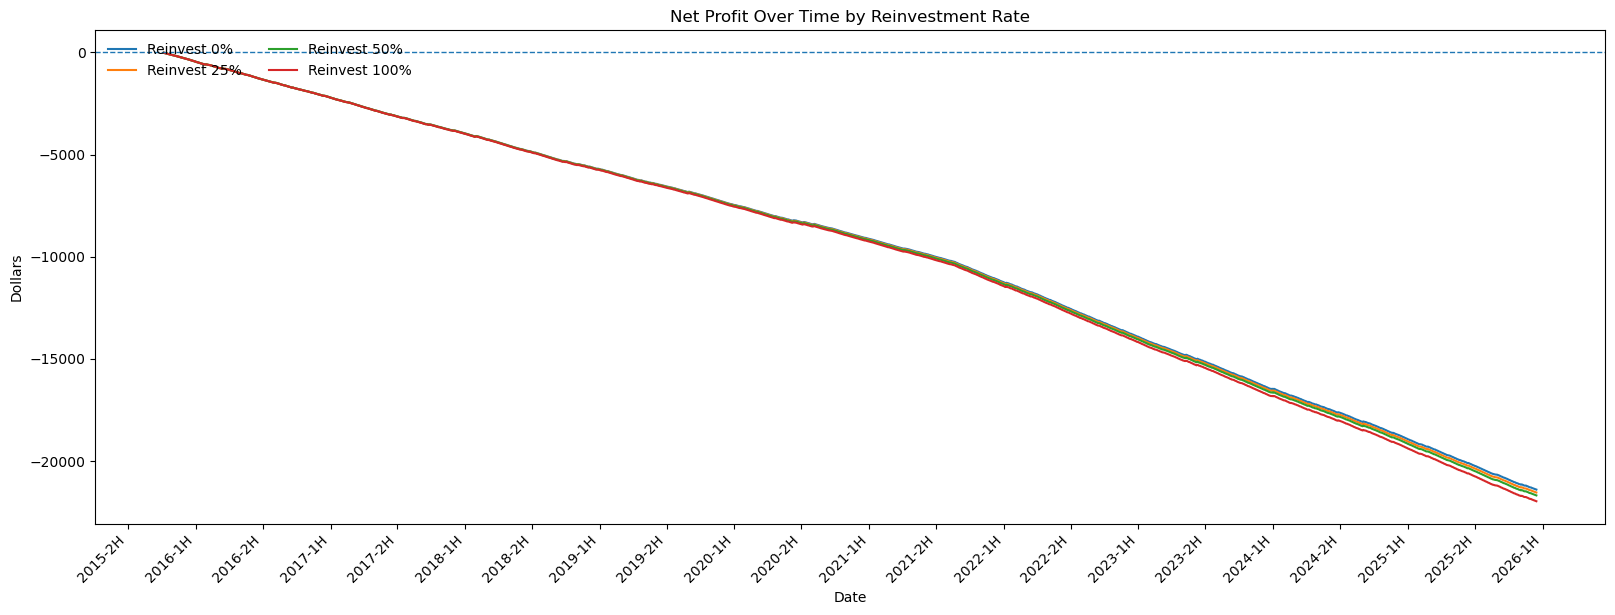

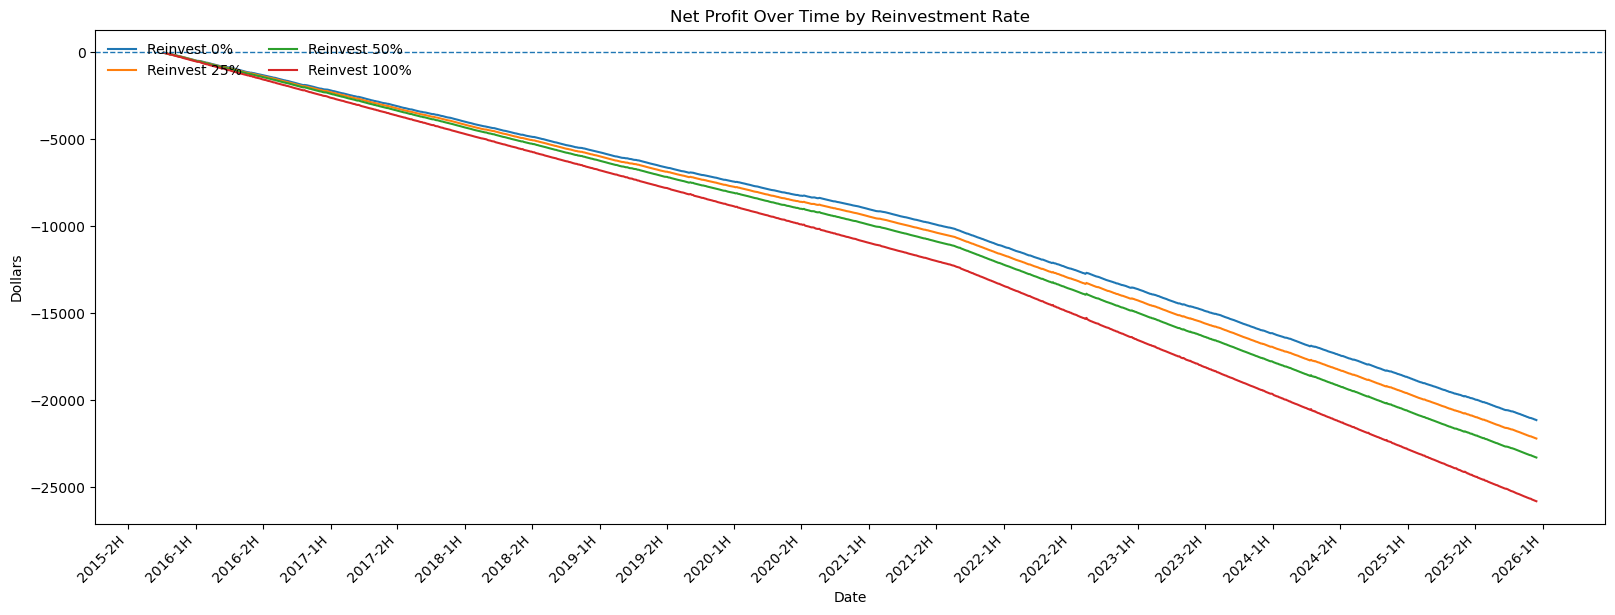

available  spend  draw_payout  draw_net  reinvested  \
reinvest_rate date                                                              
0.0           2015-10-07       20.0   20.0          0.0     -20.0         0.0   
              2015-10-10       20.0   20.0          0.0     -20.0         0.0   
              2015-10-14       20.0   20.0          8.0     -12.0         0.0   
              2015-10-17       20.0   20.0          0.0     -20.0         0.0   
              2015-10-21       20.0   20.0          0.0     -20.0         0.0   

                          withdrawn  withdrawn_balance  bankroll_cash  \
reinvest_rate date                                                      
0.0           2015-10-07        0.0           0.000000            0.0   
              2015-10-10        0.0           0.000000            0.0   
              2015-10-14        8.0           8.000000            0.0   
              2015-10-17        0.0           8.001942            0.0   
              2015-10-21        0.0           8.004533            0.0   

                            equity  contributed  net_profit  rolling_pnl  \
reinvest_rate date                                                         
0.0           2015-10-07  0.000000         20.0  -20.000000          NaN   
              2015-10-10  0.000000         40.0  -40.000000          NaN   
              2015-10-14  8.000000         60.0  -52.000000          NaN   
              2015-10-17  8.001942         80.0  -71.998058          NaN   
              2015-10-21  8.004533        100.0  -91.995467          NaN   

                          rolling_volatility  rolling_sharpe       roi  \
reinvest_rate date                                                       
0.0           2015-10-07                 NaN             NaN  0.180803   
              2015-10-10                 NaN             NaN  0.180803   
              2015-10-14                 NaN             NaN  0.180803   
              2015-10-17                 NaN             NaN  0.180803   
              2015-10-21                 NaN             NaN  0.180803   

                          net_profit_final  final_equity  \
reinvest_rate date                                         
0.0           2015-10-07       -21135.2819     4664.7181   
              2015-10-10       -21135.2819     4664.7181   
              2015-10-14       -21135.2819     4664.7181   
              2015-10-17       -21135.2819     4664.7181   
              2015-10-21       -21135.2819     4664.7181   

                          total_contributed_final  
reinvest_rate date                                 
0.0           2015-10-07                  25800.0  
              2015-10-10                  25800.0  
              2015-10-14                  25800.0  
              2015-10-17                  25800.0  
              2015-10-21                  25800.0

In [7]:
# Same ticket count each draw (isolates accounting effects)
df_fixed = bt.compare_reinvest_rates(
    reinvest_rates=(0.0, 0.25, 0.5, 1.0),
    seed=20250101,
    mode="fixed_exposure",
    plot=True,
)

# “Reinvest buys more tickets” while keeping runs comparable via nested pools
df_nested = bt.compare_reinvest_rates(
    reinvest_rates=(0.0, 0.25, 0.5, 1.0),
    seed=20250101,
    mode="nested_compounding",
    plot=True,
)

df_nested.head()

### 4) Model “withdraw winnings into an external account” (withdrawal_apy + draws_per_year)

In [8]:
bt = PowerballBacktester(
    draw_csv="powerball.csv",
    jackpot_csv="jackpots.csv",
    generator=gen,
    ticket_budget=100,
    reinvest_percent=0.50,   # half reinvest, half withdraw
    withdrawal_apy=0.05,     # external compounding on withdrawals
    draws_per_year=104,      # used to convert APY to per-draw rate
    max_T=200
)

out = bt.run(seed=7)
out

,date,available,spend,draw_payout,draw_net,reinvested,withdrawn,withdrawn_balance,bankroll_cash,equity,contributed,net_profit,rolling_pnl,rolling_volatility,rolling_sharpe
0,10/07/2015,100.0,100.0,12.0,-88.0,6.0,6.0,6.000000,6.0,12.000000,100.0,-88.000000,NaN,NaN,NaN
1,10/10/2015,106.0,106.0,8.0,-98.0,4.0,4.0,10.002405,4.0,14.002405,200.0,-185.997595,NaN,NaN,NaN
2,10/14/2015,104.0,104.0,24.0,-80.0,12.0,12.0,22.007751,12.0,34.007751,300.0,-265.992249,NaN,NaN,NaN
3,10/17/2015,112.0,112.0,4.0,-108.0,2.0,2.0,24.016572,2.0,26.016572,400.0,-373.983428,NaN,NaN,NaN
4,10/21/2015,102.0,102.0,16.0,-86.0,8.0,8.0,32.029408,8.0,40.029408,500.0,-459.970592,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1285,12/06/2025,112.0,112.0,0.0,-112.0,0.0,0.0,13585.076433,0.0,13585.076433,128600.0,-115014.923567,-2776.0,19.085530,-26.555507
1286,12/08/2025,100.0,100.0,16.0,-84.0,8.0,8.0,13596.706312,8.0,13604.706312,128700.0,-115095.293688,-2801.0,18.090736,-28.268076
1287,12/10/2025,108.0,108.0,24.0,-84.0,12.0,12.0,13612.339298,12.0,13624.339298,128800.0,-115175.660702,-2755.0,16.780702,-29.974425
1288,12/13/2025,112.0,112.0,8.0,-104.0,4.0,4.0,13621.795408,4.0,13625.795408,128900.0,-115274.204592,-2775.0,16.855880,-30.057367


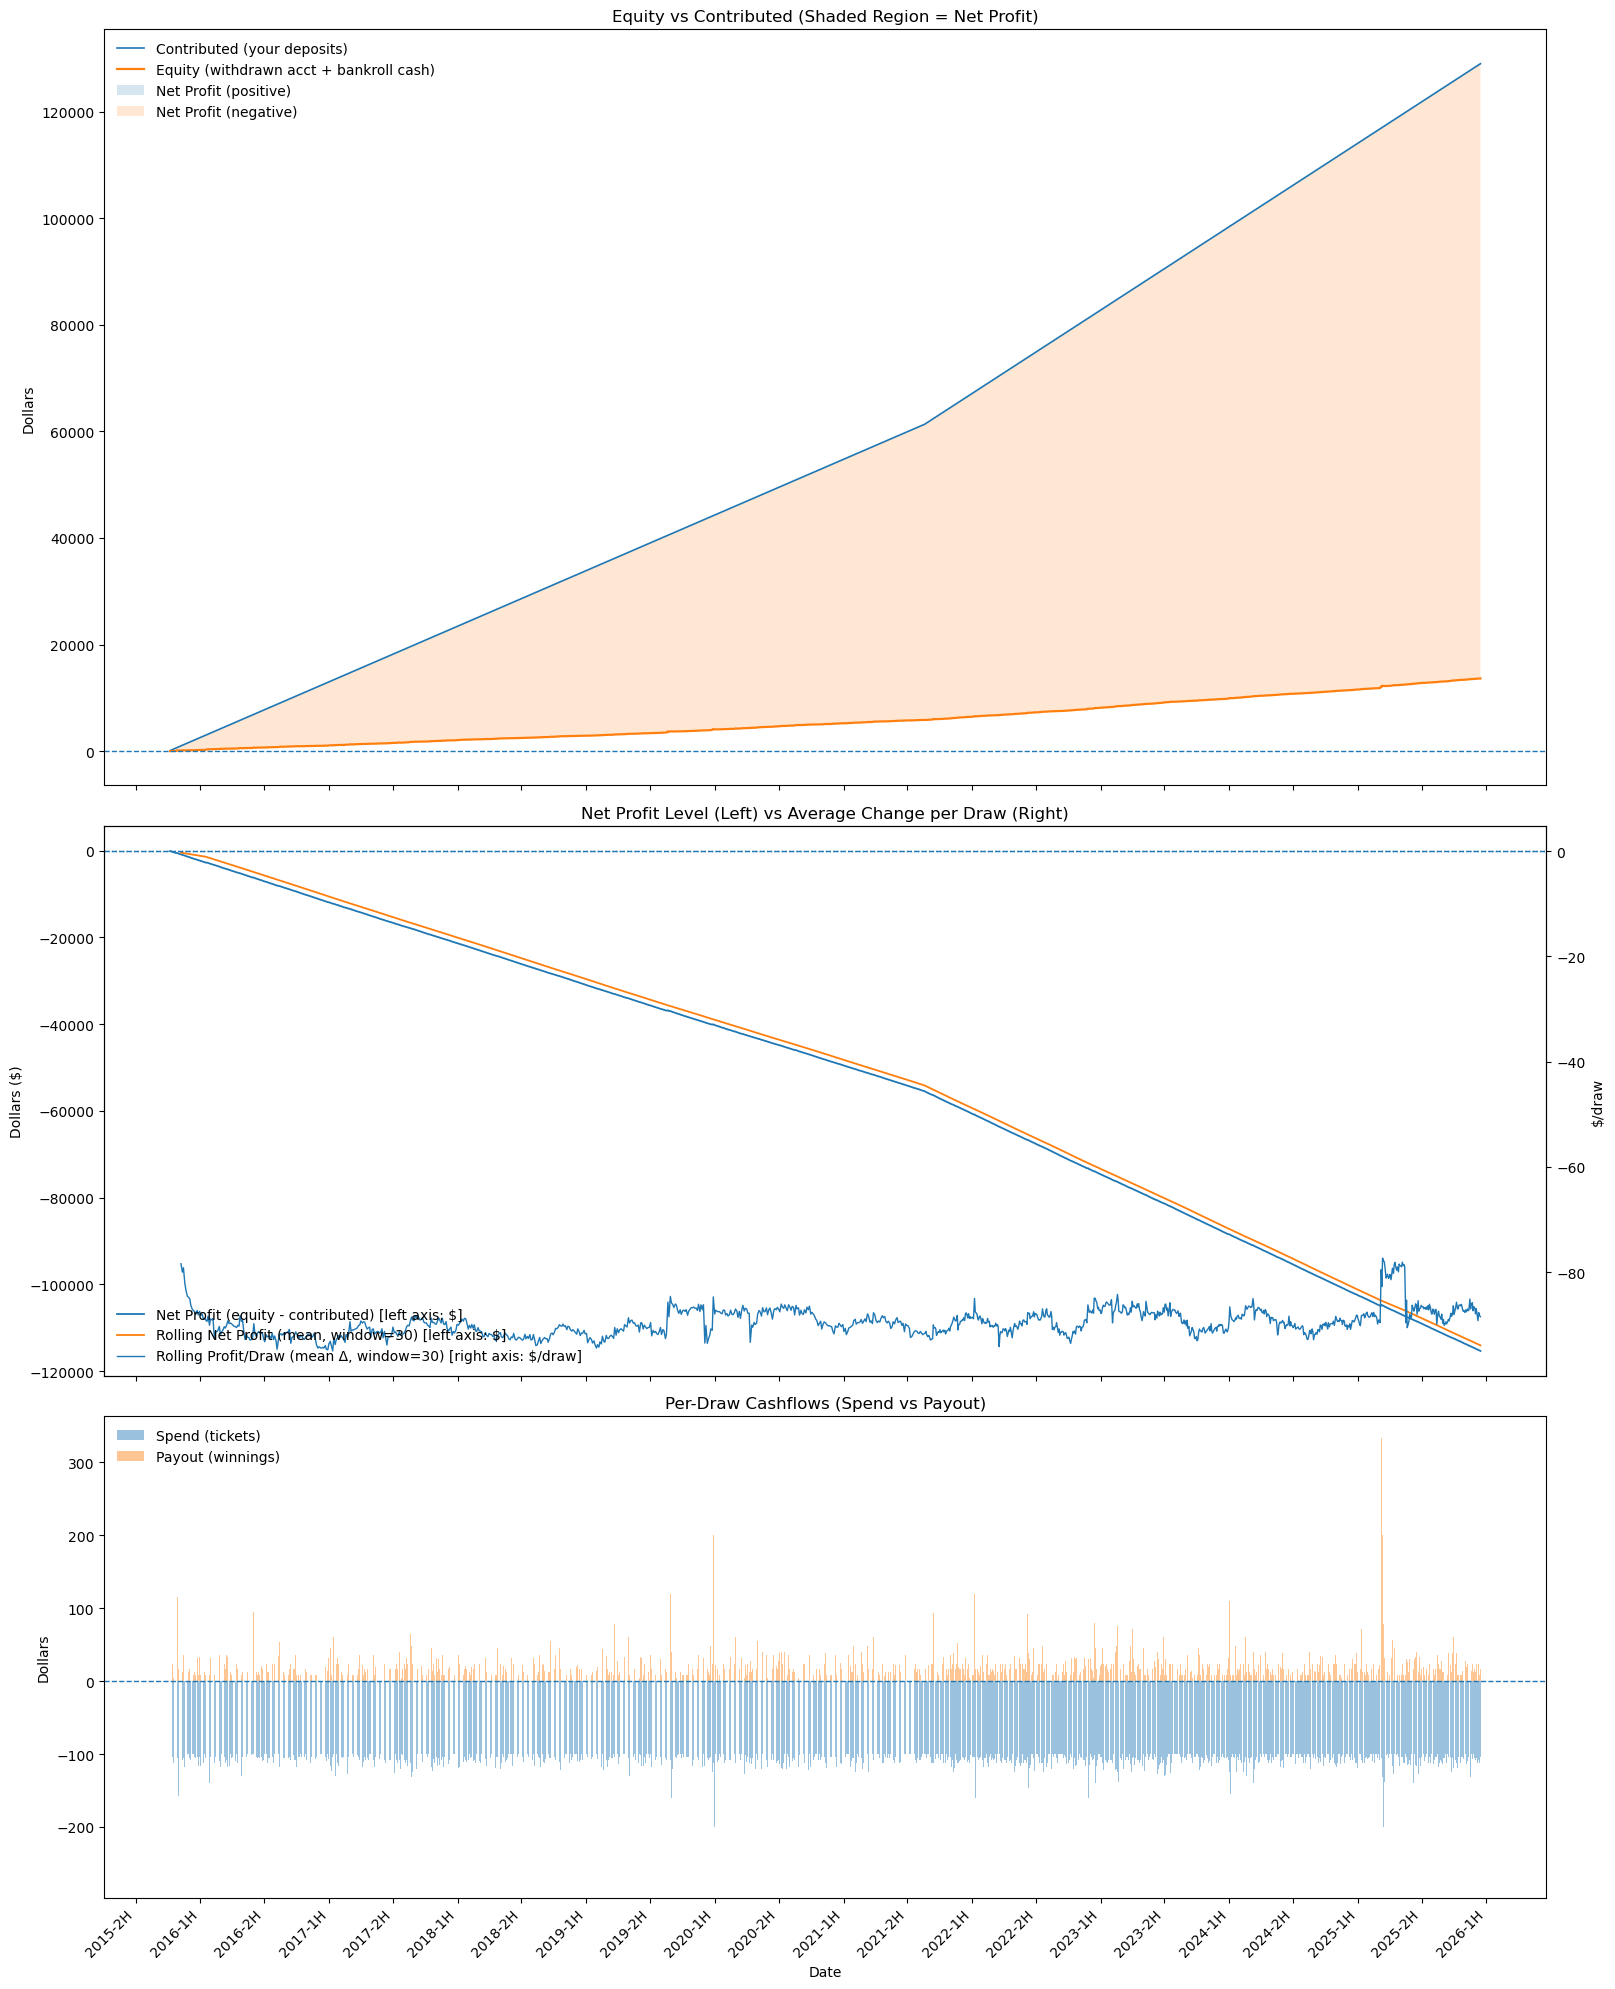

In [9]:
bt.plot_winnings(out)

### 5) Plot a single run with dual-axis “net profit level vs profit/draw” and cashflows

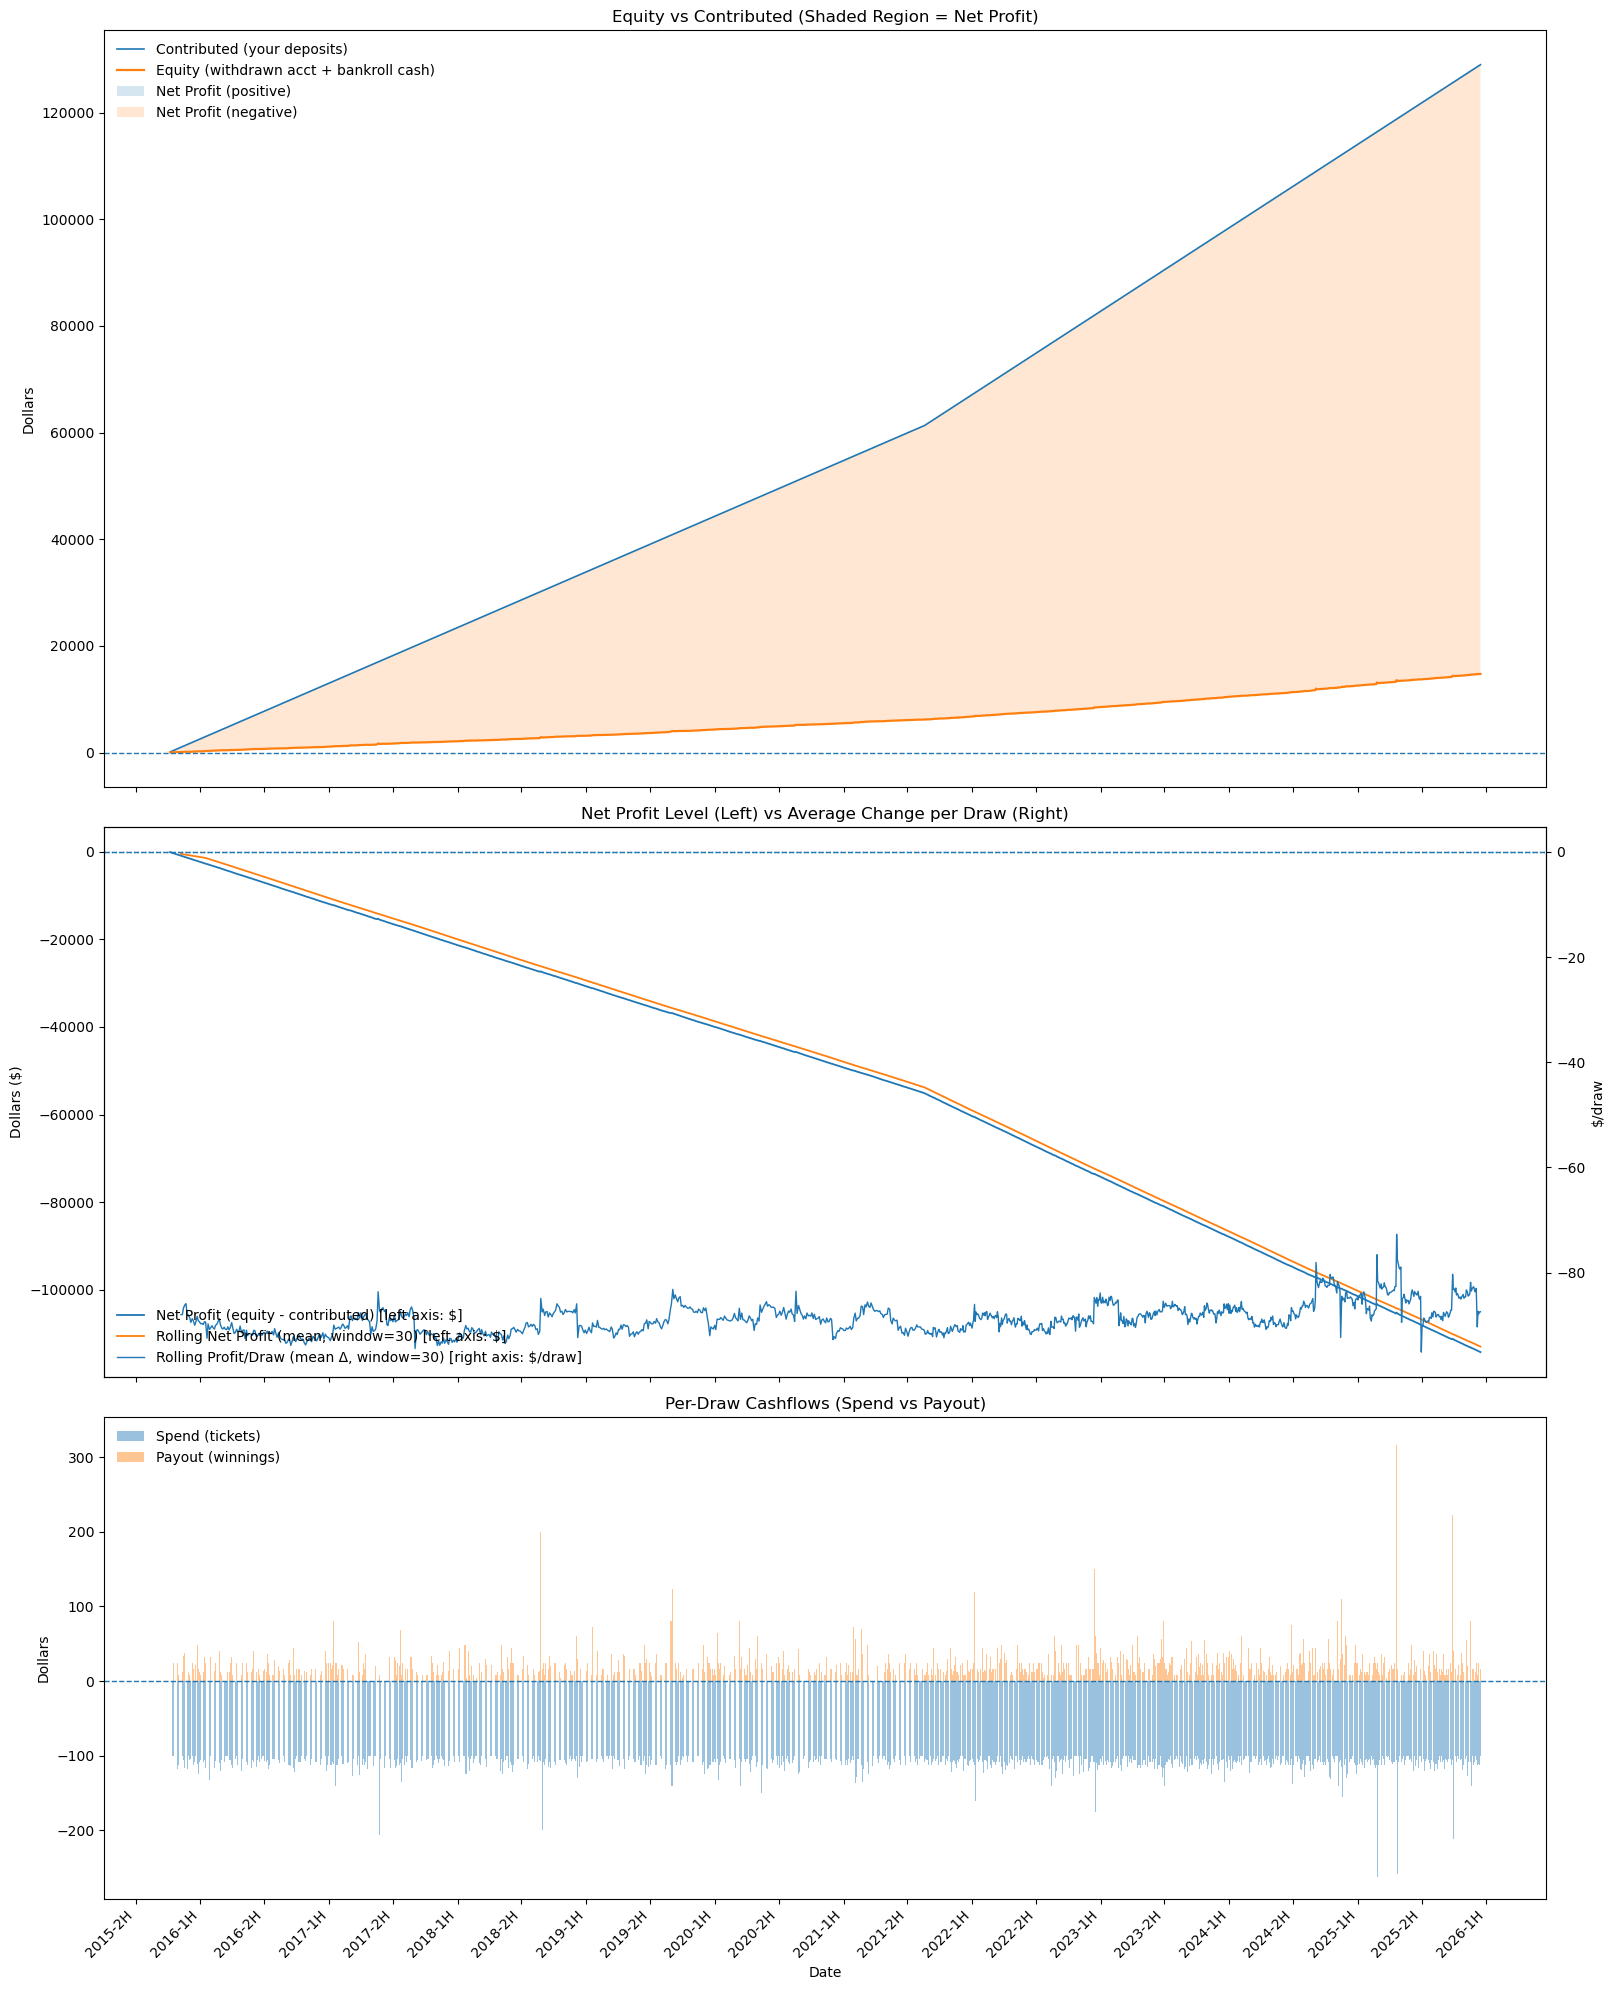

In [10]:
out = bt.run(seed=123)
bt.plot_winnings(out)
# optional:
ticket_df = bt.last_ticket_detail
summary = bt.last_summary

### 6) Temperature-stratified performance (deciles of white temperature)

In [11]:
draw_detail = bt.run(seed=123)  # run() returns draw_detail now :contentReference[oaicite:1]{index=1}
ticket_detail = bt.last_ticket_detail  # populated by run() :contentReference[oaicite:2]{index=2}

summary = bt.summarize_by_white_temperature_deciles(ticket_detail, q=10)
summary

,mean_payout,hit_rate,n
temp_bin,,,
"(0.00722, 82.798]",0.508003,0.040017,4748
"(82.798, 131.607]",0.497577,0.041500,4747
"(131.607, 159.869]",0.416263,0.039393,4747
"(159.869, 176.714]",0.512324,0.043606,4747
"(176.714, 186.755]",0.527491,0.042764,4747
"(186.755, 192.53]",0.476090,0.041500,4747
"(192.53, 196.023]",0.453128,0.042132,4747
"(196.023, 198.083]",0.546450,0.041079,4747
"(198.083, 199.289]",0.482199,0.042343,4747


### 7) Performance run: turn off metadata to reduce overhead (store_temperatures=False)

In [12]:
bt_fast = PowerballBacktester(
    draw_csv="powerball.csv",
    jackpot_csv="jackpots.csv",
    generator=gen,
    ticket_budget=500,
    store_temperatures=False,  # leaner generation; no temp columns
    prefer_numba=True,
)

draw_detail = bt_fast.run(seed=123)  # returns draw_detail :contentReference[oaicite:3]{index=3}
ticket_detail = bt_fast.last_ticket_detail  # populated by run() :contentReference[oaicite:4]{index=4}

print(ticket_detail.columns)  # should not include white_temperature/red_temperature

Index(['date', 'cost', 'payout', 'multiplier', 'white_1', 'white_2', 'white_3',
       'white_4', 'white_5', 'red_ball'],
      dtype='object')


### 8) Verify multiplier economics and budget allocation behavior

In [13]:
bt_alloc = PowerballBacktester(
    draw_csv="powerball.csv",
    jackpot_csv="jackpots.csv",
    generator=gen,
    ticket_budget=7,
    use_multiplier=True,
)

# Internal allocation logic: (n_multiplier, n_non_multiplier)
print(bt_alloc._allocate_ticket_counts(7))   # expected pattern like (1, 2)
print(bt_alloc._allocate_ticket_counts(10))  # expected pattern like (2, 2)

(1, 2)
(2, 2)


### 9) Enforced uniqueness across multiplier and non-multiplier pools (per draw)

In [14]:
bt = PowerballBacktester(
    draw_csv="powerball.csv",
    jackpot_csv="jackpots.csv",
    generator=gen,            # must support existing_tickets=...
    ticket_budget=101,
    use_multiplier=True,
)

draw_detail = bt.run(seed=99)          # returns draw_detail :contentReference[oaicite:5]{index=5}
td = bt.last_ticket_detail             # ticket-level rows :contentReference[oaicite:6]{index=6}

dupes = td.duplicated(
    subset=["date", "white_1", "white_2", "white_3", "white_4", "white_5", "red_ball"]
).sum()

print("duplicate tickets within a draw:", dupes)

duplicate tickets within a draw: 0


### 10) Use the generator standalone (CSV-friendly ticket export + uniqueness controls)

In [15]:
gen = TemperatureLotteryGenerator(
    csv_path="powerball.csv",
    T_white_min=0.0,
    T_red_min=0.0,
    temperature_scale=200.0,          # makes 200 map to alpha≈1
    temperature_sampling="rev_log1p", # mostly high T, few low T
)

# Cashier-friendly output (flat columns)
tickets = gen.generate_ticket_batch(
    n=10,
    max_T=50.0,
    include_metadata=False,
    ensure_unique=True,
)

# Export-ready
df = pd.DataFrame(tickets)
df.to_csv("tickets.csv", index=False)

# Enforce uniqueness vs an existing pool (e.g., “don’t repeat last week’s tickets”)
more = gen.generate_ticket_batch(
    n=10,
    max_T=50.0,
    include_metadata=True,
    ensure_unique=True,
    existing_tickets=tickets,
)

df

,white_1,white_2,white_3,white_4,white_5,red_ball
0,36,37,56,58,66,1
1,6,33,35,37,54,9
2,23,42,46,55,69,10
3,18,26,36,46,48,21
4,35,37,38,48,60,8
5,16,17,23,27,33,6
6,19,20,28,45,65,14
7,2,18,21,36,48,14
8,4,24,35,54,58,3
9,2,5,7,41,44,6


In [16]:
pd.DataFrame(more)

,white_balls,red_ball,T_white,T_red,max_T
0,"[1, 7, 11, 45, 68]",22,47.040494,48.703245,50.0
1,"[2, 13, 16, 27, 32]",5,40.308537,35.080756,50.0
2,"[10, 39, 44, 54, 62]",24,40.008318,48.962542,50.0
3,"[14, 18, 22, 33, 60]",6,11.630249,45.542678,50.0
4,"[8, 45, 58, 59, 64]",12,32.060655,42.223913,50.0
5,"[22, 36, 48, 54, 63]",4,44.903426,40.519710,50.0
6,"[8, 14, 18, 35, 68]",2,49.470042,39.442334,50.0
7,"[9, 19, 43, 49, 60]",21,44.217163,42.401024,50.0
8,"[2, 7, 20, 43, 52]",10,13.903725,1.117111,50.0
9,"[3, 12, 16, 17, 67]",26,49.958226,44.821700,50.0


In [ ]:
import numpy as np
import pandas as pd

from powerball_backtester import PowerballBacktester
from powerball_ml_ticket_generator import PowerballMLTicketGenerator  # wherever you saved the class
from scipy.stats import randint, loguniform

'''
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Unit time (1 head, 1 ensemble member, full search): 281.3 seconds
Estimated total (upper bound, red ~= white): 4.22 hours
Estimated total (red ~ 0.5 * white):         3.87 hours

With mc_strategy="repeated_random_search" multipy by 33.5 for 40 n_iter
With mc_strategy="repeated_random_search" multipy by 16.8 for 20 n_iter
'''

param_space = {
    # With default max_iter (100), LR too small tends to underfit; too large can destabilize.
    "model__learning_rate": loguniform(0.02, 0.12),

    # Keep trees modest; you have ~230 engineered features and (for whites) ~9k augmented rows.
    "model__max_leaf_nodes": randint(15, 80),        # [15..79]

    # Must work for red head too (only ~903 train rows), so don’t push leaf sizes too high.
    "model__min_samples_leaf": randint(10, 80),      # [10..79]

    # Regularization: avoid huge values; log scale gives diversity without wasting samples.
    "model__l2_regularization": loguniform(1e-4, 1.0),

    # Depth: include None for “leaf-node-limited” growth; otherwise keep moderate.
    "model__max_depth": [None, 2, 3, 4, 5, 6],

    # Histogram bin count; trades training speed vs split granularity (higher = finer, slower)
    "model__max_bins": randint(64, 256),   # [64..255]
}

ml = PowerballMLTicketGenerator(
    draw_data="powerball.csv",
    lag_n=15,
    rolling_windows=(5, 10, 20),
    augment_permutations=10,
    use_quantile=False,                 # OFF for boosting
    enable_tuning=True,
    mc_ensemble_size=9,                 # must be >= max ensemble_size you want to test later
    mc_strategy="repeated_random_search",
    tuning_n_iter=15,
    tuning_cv_splits=5,                 # TimeSeriesSplit on train only
    param_distributions=param_space,
    seed=123,
    verbose=True,
).fit()

print(ml.evaluate(split="val"))

# Save without embedding draws (smaller artifact)
ml.save_state("boosted_trees_powerball.joblib", include_draws=False)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


In [ ]:
# Later: load and provide draw_data
ml = PowerballMLTicketGenerator.load_state(
    "boosted_trees_powerball.joblib",
    draw_data="powerball.csv",
)

tickets = ml.generate_tickets(n=20, temperature=1.0, as_flat=True)
print(tickets[0])

In [ ]:
from powerball_ml_policy import policy_search_on_val, MLBacktesterGenerator
from powerball_backtester import PowerballBacktester

# 1) pick policy on val
best_policy, policy_df = policy_search_on_val(
    ml,
    draw_csv="powerball.csv",
    jackpot_csv="jackpots.csv",
    ticket_budget=20,
    use_multiplier=False,
)

T_star = float(best_policy["temperature"])
M_star = int(best_policy["ensemble_size"])

# 2) run backtest using chosen policy
gen_star = MLBacktesterGenerator(ml, temperature=T_star, ensemble_size=M_star, seed=123)

bt = PowerballBacktester(
    draw_csv="powerball.csv",
    jackpot_csv="jackpots.csv",
    generator=gen_star,
    ticket_budget=20,
    use_multiplier=False,
    reinvest_percent=0.0,
    store_temperatures=True,
    seed=123,
)

pnl = bt.run(seed=123)  # run() returns a draw-level DataFrame and sets bt.last_ticket_detail :contentReference[oaicite:3]{index=3}
ticket_detail = bt.last_ticket_detail

print(pnl.tail())
print("Final net_profit:", float(pnl["net_profit"].iloc[-1]))
print("Ticket rows:", ticket_detail.shape)

# 3) TEST-window incremental profit
n_train = len(ml.splits_.X_train)
n_val = len(ml.splits_.X_val)
n_test = len(ml.splits_.X_test)

test_start = (n_train + n_val) + 1
test_end = (n_train + n_val + n_test)

pnl_test = pnl.iloc[test_start:test_end + 1]
test_profit = float((pnl_test["draw_payout"] - pnl_test["spend"]).sum())
print("Incremental profit over TEST window:", test_profit)


In [ ]:
from powerball_ml_ticket_generator import PowerballMLTicketGenerator
from powerball_ml_policy import MLBacktesterGenerator
from powerball_backtester import PowerballBacktester

ml = PowerballMLTicketGenerator(draw_data="powerball.csv", enable_tuning=False, mc_ensemble_size=1, augment_permutations=0).fit()
gen = MLBacktesterGenerator(ml, temperature=1.0, ensemble_size=1, seed=123)

bt = PowerballBacktester(draw_csv="powerball.csv", jackpot_csv="jackpots.csv", generator=gen, ticket_budget=6, use_multiplier=True, reinvest_percent=0.0)
bt.run()
print(bt.last_summary)